In [1]:
import pandas as pd

In [2]:
ton_iot_dataset = pd.read_csv("train_test_network.csv")
simulation_dataset = pd.read_csv("dataset_training_iot.csv")
testbed_dataset = pd.read_csv("new_dataset_training_iot.csv")

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Simulation loaded: {simulation_dataset.shape}")
print(f"Testbed loaded   : {testbed_dataset.shape}")

TON-IoT loaded   : (211043, 44)
Simulation loaded: (36100, 47)
Testbed loaded   : (604581, 43)


In [3]:
for name, df in [("TON-IoT", ton_iot_dataset), ("Simulation", simulation_dataset), ("Testbed", testbed_dataset)]:
    print(f"\n--- {name} ---")
    print(df['label'].value_counts())
    print(df['type'].value_counts())


--- TON-IoT ---
label
1    161043
0     50000
Name: count, dtype: int64
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

--- Simulation ---
label
1    30986
0     5114
Name: count, dtype: int64
type
injection    5769
normal       5114
ddos         5094
mitm         5086
password     5037
dos          5000
scanning     5000
Name: count, dtype: int64

--- Testbed ---
label
0    378987
1    225594
Name: count, dtype: int64
type
normal       378987
injection     90795
dos           45289
password      32627
ddos          21456
scanning      19998
mitm          15429
Name: count, dtype: int64


In [4]:
for df in [ton_iot_dataset, simulation_dataset, testbed_dataset]:
    df.replace("-", "n/a", inplace=True)
    df.drop_duplicates(inplace=True)

print(f"TON-IoT after dedup   : {ton_iot_dataset.shape}")
print(f"Simulation after dedup: {simulation_dataset.shape}")
print(f"Testbed after dedup   : {testbed_dataset.shape}")

TON-IoT after dedup   : (190474, 44)
Simulation after dedup: (13104, 47)
Testbed after dedup   : (197022, 43)


In [5]:
for name, df in [("TON-IoT", ton_iot_dataset), ("Simulation", simulation_dataset), ("Testbed", testbed_dataset)]:
    print(f"\n--- {name} ---")
    print(df['label'].value_counts())
    print(df['type'].value_counts())


--- TON-IoT ---
label
1    148434
0     42040
Name: count, dtype: int64
type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64

--- Simulation ---
label
1    12917
0      187
Name: count, dtype: int64
type
dos          4985
scanning     4613
injection    2861
ddos          195
normal        187
password      132
mitm          131
Name: count, dtype: int64

--- Testbed ---
label
1    136620
0     60402
Name: count, dtype: int64
type
injection    90582
normal       60402
password     32619
mitm         10380
ddos          1430
dos           1330
scanning       279
Name: count, dtype: int64


In [6]:
DROP_COLS = ['src_ip', 'dst_ip', 'src_port', 'dst_port']

def drop_meta(df):
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])

ton_iot_dataset = drop_meta(ton_iot_dataset)
simulation_dataset = drop_meta(simulation_dataset)
testbed_dataset = drop_meta(testbed_dataset)

In [7]:
all_columns = sorted(
    set(ton_iot_dataset.columns) |
    set(simulation_dataset.columns) |
    set(testbed_dataset.columns)
)

def realign_columns(df, columns):
    for c in columns:
        if c not in df.columns:
            df[c] = 'n/a'
    return df[columns]

ton_iot_dataset    = realign_columns(ton_iot_dataset,    all_columns)
simulation_dataset = realign_columns(simulation_dataset, all_columns)
testbed_dataset    = realign_columns(testbed_dataset,    all_columns)

print(f"All datasets realigned to {len(all_columns)} columns.")

All datasets realigned to 49 columns.


In [8]:
binary_columns = ["dns_query",
                  "ssl_version", "ssl_cipher", "ssl_subject", "ssl_issuer",
                  "http_uri", "http_user_agent", "http_orig_mime_types", "http_resp_mime_types",
                  "weird_name", "history", "mqtt_topic", "mqtt_qos",
                  ]

dataset_sources = {
                    "ton_iot": ton_iot_dataset,
                    "simulation": simulation_dataset,
                    "testbed": testbed_dataset,
                }

combined_dataset = pd.concat([df.assign(source=name) for name, df in dataset_sources.items()],ignore_index=True,)

dataset_counts = combined_dataset["source"].value_counts().to_dict()
print(dataset_counts)

{'testbed': 197022, 'ton_iot': 190474, 'simulation': 13104}


In [9]:
#find categorical columns not in binary_columns
categorical_columns = [c for c in combined_dataset.columns if combined_dataset[c].dtype == "object" and c not in binary_columns and c != "source"]
print(f"Categorical columns: {categorical_columns}")

#drop type column since it is redundant with label
combined_dataset.drop(columns=["type"], inplace=True)
categorical_columns.remove("type")

for col in categorical_columns + binary_columns:
    combined_dataset[col] = combined_dataset[col].astype('category')

Categorical columns: ['conn_state', 'dns_AA', 'dns_RA', 'dns_RD', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_rejected', 'http_method', 'http_request_body_len', 'http_response_body_len', 'http_trans_depth', 'http_version', 'mqtt_from_client', 'mqtt_operation', 'mqtt_payload_len', 'mqtt_retain', 'mqtt_status', 'mqtt_topic_len', 'proto', 'service', 'ssl_established', 'ssl_resumed', 'type', 'weird_addl', 'weird_notice']


In [10]:
combined_dataset = pd.get_dummies(combined_dataset, columns=categorical_columns, sparse=False)

combined_dataset.head()

,dns_query,dst_bytes,dst_ip_bytes,dst_pkts,duration,history,http_orig_mime_types,http_resp_mime_types,http_status_code,http_uri,...,ssl_established_T,ssl_established_n/a,ssl_resumed_F,ssl_resumed_T,ssl_resumed_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a
0,n/a,2592.0,3832.0,31.0,290.371539,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
1,n/a,0.0,40.0,1.0,0.000102,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
2,n/a,0.0,40.0,1.0,0.000148,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
3,n/a,0.0,40.0,1.0,0.000113,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
4,n/a,0.0,40.0,1.0,0.000130,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True


In [11]:
for col in binary_columns:
    combined_dataset[col] = (combined_dataset[col] != 'n/a').astype(int)

combined_dataset.head()

,dns_query,dst_bytes,dst_ip_bytes,dst_pkts,duration,history,http_orig_mime_types,http_resp_mime_types,http_status_code,http_uri,...,ssl_established_T,ssl_established_n/a,ssl_resumed_F,ssl_resumed_T,ssl_resumed_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a
0,0,2592.0,3832.0,31.0,290.371539,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
1,0,0.0,40.0,1.0,0.000102,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
2,0,0.0,40.0,1.0,0.000148,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
3,0,0.0,40.0,1.0,0.000113,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
4,0,0.0,40.0,1.0,0.000130,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True


In [12]:
ton_iot_dataset    = combined_dataset[combined_dataset["source"] == "ton_iot"].drop(columns=["source"])
simulation_dataset = combined_dataset[combined_dataset["source"] == "simulation"].drop(columns=["source"])
testbed_dataset    = combined_dataset[combined_dataset["source"] == "testbed"].drop(columns=["source"])

print(f"TON-IoT final shape   : {ton_iot_dataset.shape}")
print(f"Simulation final shape: {simulation_dataset.shape}")
print(f"Testbed final shape   : {testbed_dataset.shape}")

TON-IoT final shape   : (190474, 300)
Simulation final shape: (13104, 300)
Testbed final shape   : (197022, 300)


In [13]:
from sklearn.model_selection import train_test_split
testbed_train, testbed_inference = train_test_split(testbed_dataset, test_size=0.5, random_state=42)

print(f"Testbed train shape   : {testbed_train.shape}")
print(f"Testbed inference shape   : {testbed_inference.shape}")

Testbed train shape   : (98511, 300)
Testbed inference shape   : (98511, 300)


In [14]:
train_dataset = pd.concat([ton_iot_dataset, simulation_dataset, testbed_train], ignore_index=True)

In [15]:
#determine amount of missing values in each column of train_dataset
missing_values = train_dataset.isnull().sum()

print(missing_values[missing_values > 0])

#get indices of rows with missing values
missing_indices = train_dataset[train_dataset.isnull().any(axis=1)].index
print(len(missing_indices))

#remove rows with missing values
train_dataset.drop(index=missing_indices, inplace=True)

print(f"Train dataset shape after removing missing values: {train_dataset.shape}")

dst_bytes       1380
dst_ip_bytes    1380
dst_pkts        1380
duration        1380
missed_bytes    1380
src_bytes       1380
src_ip_bytes    1380
src_pkts        1380
dtype: int64
1380
Train dataset shape after removing missing values: (300709, 300)


In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(train_dataset.drop(columns=["label"]), train_dataset["label"])

print(f"Train dataset before SMOTE: {train_dataset.drop(columns=['label']).shape}, {train_dataset['label'].shape}")
print(f"Train dataset after SMOTE: {X_train.shape}, {y_train.shape}")

Train dataset before SMOTE: (300709, 299), (300709,)
Train dataset after SMOTE: (456284, 299), (456284,)


In [17]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Internal train set: {X_train.shape}, {y_train.shape}")
print(f"Internal val set: {X_val.shape}, {y_val.shape}")

Internal train set: (342213, 299), (342213,)
Internal val set: (114071, 299), (114071,)


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import optuna
from sklearn.metrics import f1_score

def objective_dt(trial):
    param = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy','log_loss']),
        'splitter': trial.suggest_categorical('splitter', ['best', 'random']),
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1),
        'random_state': 42,
    }
    model = DecisionTreeClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    return f1

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=100)

[I 2026-05-05 13:09:50,027] A new study created in memory with name: no-name-8199e7c4-3aa2-42b2-8272-096e3e77c79f
[I 2026-05-05 13:09:51,031] Trial 0 finished with value: 0.8676839900881884 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 6, 'max_features': 'sqrt', 'ccp_alpha': 0.09118445758318922}. Best is trial 0 with value: 0.8676839900881884.
[I 2026-05-05 13:09:51,852] Trial 1 finished with value: 0.66666277044639 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 6, 'max_features': 'log2', 'ccp_alpha': 0.09218990557380352}. Best is trial 0 with value: 0.8676839900881884.
[I 2026-05-05 13:09:59,755] Trial 2 finished with value: 0.9429724638981074 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 10, 'max_features': None, 'ccp_alpha': 0.08596630018644233}. Best is trial 2 with value: 0.9429724638981074.
[I 2026-05-05 13:10:06,348] Trial 3 finished with value: 0.9569134109110217 and parameters: {'criterion': 'log

In [19]:
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    return f1

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=100)

[I 2026-05-05 13:17:03,378] A new study created in memory with name: no-name-038f253e-b9cd-41fd-9bab-eae6b7df6374
[I 2026-05-05 13:21:06,495] Trial 0 finished with value: 0.9646978419157269 and parameters: {'n_estimators': 167, 'max_depth': 5, 'max_features': None, 'criterion': 'entropy', 'ccp_alpha': 0.03601597535356434, 'bootstrap': False}. Best is trial 0 with value: 0.9646978419157269.
[I 2026-05-05 13:28:02,434] Trial 1 finished with value: 0.9734788302051506 and parameters: {'n_estimators': 287, 'max_depth': 5, 'max_features': None, 'criterion': 'entropy', 'ccp_alpha': 0.02269512740823905, 'bootstrap': False}. Best is trial 1 with value: 0.9734788302051506.
[I 2026-05-05 13:28:27,142] Trial 2 finished with value: 0.9506117694456853 and parameters: {'n_estimators': 240, 'max_depth': 5, 'max_features': 'sqrt', 'criterion': 'gini', 'ccp_alpha': 0.04262501671046606, 'bootstrap': False}. Best is trial 1 with value: 0.9734788302051506.
[I 2026-05-05 13:28:40,747] Trial 3 finished with 

In [20]:
print('Decision Tree Best parameters :')
for k, v in study_dt.best_params.items():
    print(f'  {k:<22}: {v}')

print('Random Forest Best parameters :')
for k, v in study_rf.best_params.items():
    print(f'  {k:<22}: {v}')

Decision Tree Best parameters :
  criterion             : log_loss
  splitter              : best
  max_depth             : 8
  max_features          : None
  ccp_alpha             : 0.0008348480695381214
Random Forest Best parameters :
  n_estimators          : 181
  max_depth             : 10
  max_features          : None
  criterion             : entropy
  ccp_alpha             : 2.621738590769505e-05
  bootstrap             : True


In [21]:
dt_best_params = study_dt.best_params.copy()
rf_best_params = study_rf.best_params.copy()

dt_model = DecisionTreeClassifier(**dt_best_params)
dt_model.fit(
    X_train, y_train,
)

dt_y_val_pred  = dt_model.predict(X_val)
dt_y_val_proba = dt_model.predict_proba(X_val)[:, 1]
print('Decision Tree Model trained.')

rf_model = RandomForestClassifier(**rf_best_params) 
rf_model.fit(
    X_train, y_train,
)
rf_y_val_pred  = rf_model.predict(X_val)
rf_y_val_proba = rf_model.predict_proba(X_val)[:, 1]
print('Random Forest Model trained.')

Decision Tree Model trained.
Random Forest Model trained.


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('=== VALIDATION SET FOR DECISION TREE ===')
print(f'Accuracy  : {accuracy_score(y_val, dt_y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, dt_y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, dt_y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, dt_y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, dt_y_val_pred))
print("Classification Report:\n", classification_report(y_val, dt_y_val_pred))

=== VALIDATION SET FOR DECISION TREE ===
Accuracy  : 0.9923
Precision : 0.9890
Recall    : 0.9956
F1        : 0.9923
Confusion Matrix:
 [[56406   630]
 [  251 56784]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     57036
           1       0.99      1.00      0.99     57035

    accuracy                           0.99    114071
   macro avg       0.99      0.99      0.99    114071
weighted avg       0.99      0.99      0.99    114071



In [23]:
print('=== VALIDATION SET FOR RANDOM FOREST ===')
print(f'Accuracy  : {accuracy_score(y_val, rf_y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, rf_y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, rf_y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, rf_y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, rf_y_val_pred))
print("Classification Report:\n", classification_report(y_val, rf_y_val_pred))

=== VALIDATION SET FOR RANDOM FOREST ===
Accuracy  : 0.9956
Precision : 0.9936
Recall    : 0.9977
F1        : 0.9956
Confusion Matrix:
 [[56667   369]
 [  131 56904]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     57036
           1       0.99      1.00      1.00     57035

    accuracy                           1.00    114071
   macro avg       1.00      1.00      1.00    114071
weighted avg       1.00      1.00      1.00    114071



In [24]:
X_test, y_test = testbed_inference.drop(columns=["label"]), testbed_inference["label"]

dt_y_holdout_pred  = dt_model.predict(X_test)
dt_y_holdout_proba = dt_model.predict_proba(X_test)[:, 1]

print('===DECISION TREE TEST SET PERFORMANCE===')
print(f'Accuracy  : {accuracy_score(y_test, dt_y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_test, dt_y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_test, dt_y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_test, dt_y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_y_holdout_pred))
print("Classification Report:\n", classification_report(y_test, dt_y_holdout_pred))

===DECISION TREE TEST SET PERFORMANCE===
Accuracy  : 0.9861
Precision : 0.9998
Recall    : 0.9801
F1        : 0.9899
Confusion Matrix:
 [[30050    12]
 [ 1360 67089]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     30062
           1       1.00      0.98      0.99     68449

    accuracy                           0.99     98511
   macro avg       0.98      0.99      0.98     98511
weighted avg       0.99      0.99      0.99     98511



In [25]:
rf_y_holdout_pred  = rf_model.predict(X_test)
rf_y_holdout_proba = rf_model.predict_proba(X_test)[:, 1]

print('===RANDOM FOREST TEST SET PERFORMANCE===')
print(f'Accuracy  : {accuracy_score(y_test, rf_y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_test, rf_y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_test, rf_y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_test, rf_y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_y_holdout_pred))
print("Classification Report:\n", classification_report(y_test, rf_y_holdout_pred))

===RANDOM FOREST TEST SET PERFORMANCE===
Accuracy  : 0.9864
Precision : 0.9997
Recall    : 0.9807
F1        : 0.9901
Confusion Matrix:
 [[30043    19]
 [ 1324 67125]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     30062
           1       1.00      0.98      0.99     68449

    accuracy                           0.99     98511
   macro avg       0.98      0.99      0.98     98511
weighted avg       0.99      0.99      0.99     98511



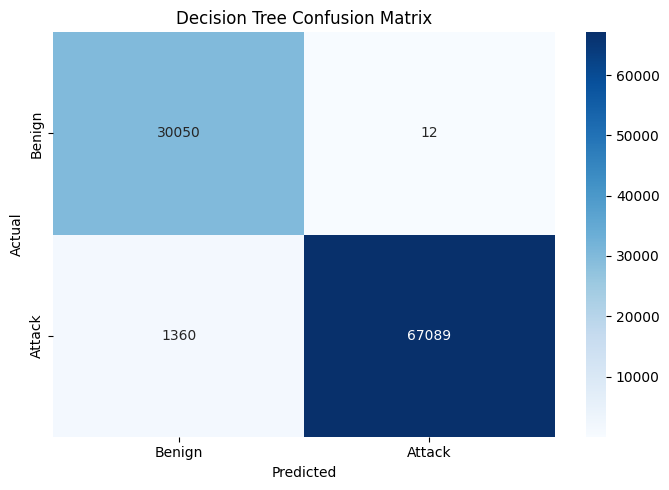

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

dt_cm = confusion_matrix(y_test, dt_y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('Decision Tree Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150)
plt.show()

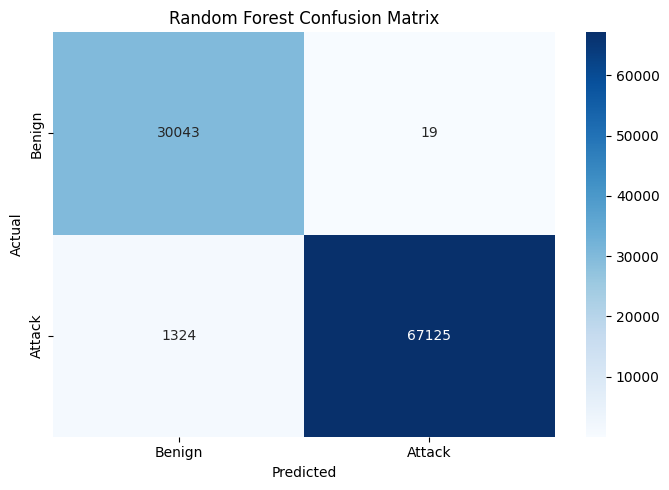

In [27]:
rf_cm = confusion_matrix(y_test, rf_y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('Random Forest Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

In [28]:
import json
import joblib

#save best parameters for each model in separate json files
with open('dt_best_params.json', 'w') as f:
    json.dump(dt_best_params, f, indent=4)
print("dt_best_params.json saved.")
with open('rf_best_params.json', 'w') as f:
    json.dump(rf_best_params, f, indent=4)
print("rf_best_params.json saved.")

#save each model as pkl file using joblib
joblib.dump(dt_model, 'dt_final.pkl')
print("dt_final.pkl saved.")
joblib.dump(rf_model, 'rf_final.pkl')
print("rf_final.pkl saved.")

dt_best_params.json saved.
rf_best_params.json saved.
dt_final.pkl saved.
rf_final.pkl saved.
